In [1]:
from sklearn.preprocessing import StandardScaler
from utils import *
from dnn import DNN
from linear_regression import LinearRegressionTorch 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [2]:
data_path = '../data/processed/'
X_train = load_data(f'{data_path}/X_train.csv').values
X_val = load_data(f'{data_path}/X_val.csv').values
X_test = load_data(f'{data_path}/X_test.csv').values
y_train = load_data(f'{data_path}/y_train.csv').values
y_val = load_data(f'{data_path}/y_val.csv').values
y_test = load_data(f'{data_path}/y_test.csv').values

In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [4]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [5]:
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: torch.Size([2132, 31]), y_train shape: torch.Size([2132, 1])
X_val shape: torch.Size([457, 31]), y_val shape: torch.Size([457, 1])
X_test shape: torch.Size([458, 31]), y_test shape: torch.Size([458, 1])


In [6]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
batch_size = 32

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

In [8]:
def pipeline(model, epochs=50):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=True, 
        early_stopping=True,
    )
    test_model(model, X_test, y_test)
    plot_loss(train_losses, val_losses)

In [9]:
epochs = 1000
learning_rate = 0.01

### Linear Regression

Early stopping at epoch 39

========= Model Evaluation =========
Mean Squared Error (MSE): 364.5160
R^2 Score: 0.5293


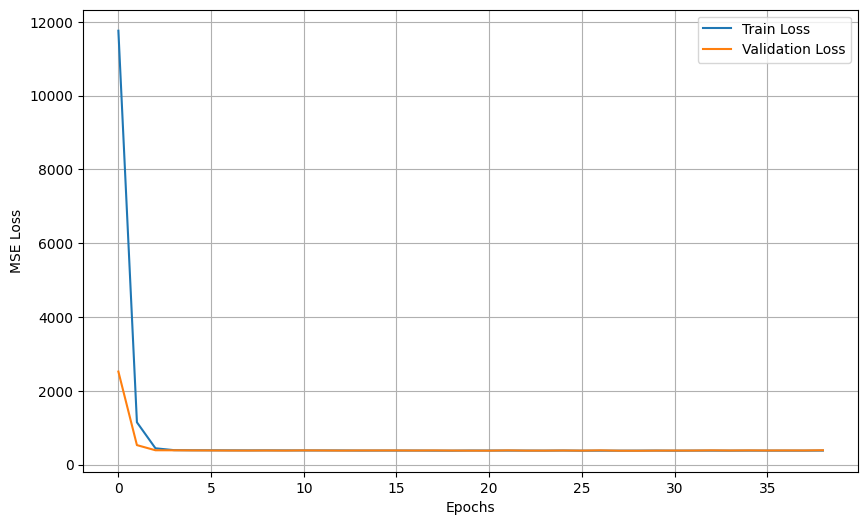

In [10]:
lr = LinearRegressionTorch(X_train.shape[1], lr=learning_rate)
pipeline(lr, epochs=epochs)

### DNN-16

In [11]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=learning_rate
)
dnn_16.model

Sequential(
  (0): Linear(in_features=31, out_features=16, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Early stopping at epoch 24

========= Model Evaluation =========
Mean Squared Error (MSE): 373.6881
R^2 Score: 0.5175


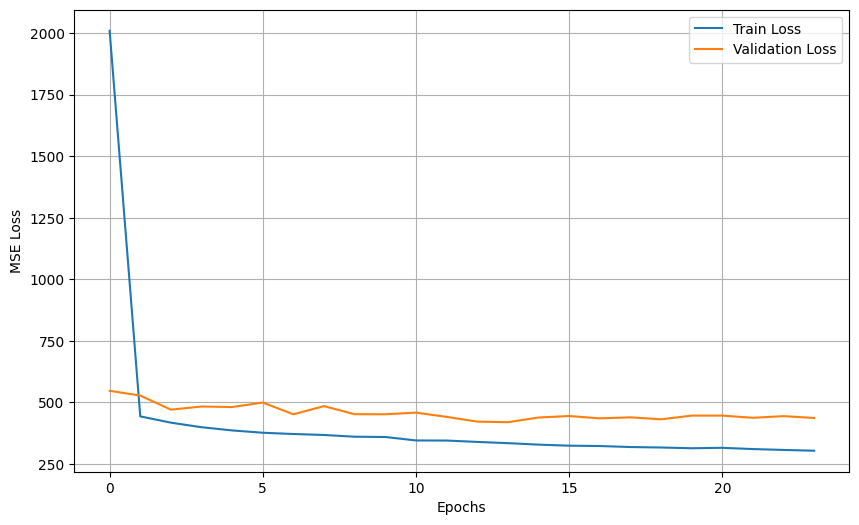

In [12]:
pipeline(dnn_16, epochs=epochs)

## DNN-30-8

In [13]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 8],
    output_dim=1,
    lr=learning_rate
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=31, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=8, out_features=1, bias=True)
)

Early stopping at epoch 20

========= Model Evaluation =========
Mean Squared Error (MSE): 357.8347
R^2 Score: 0.5380


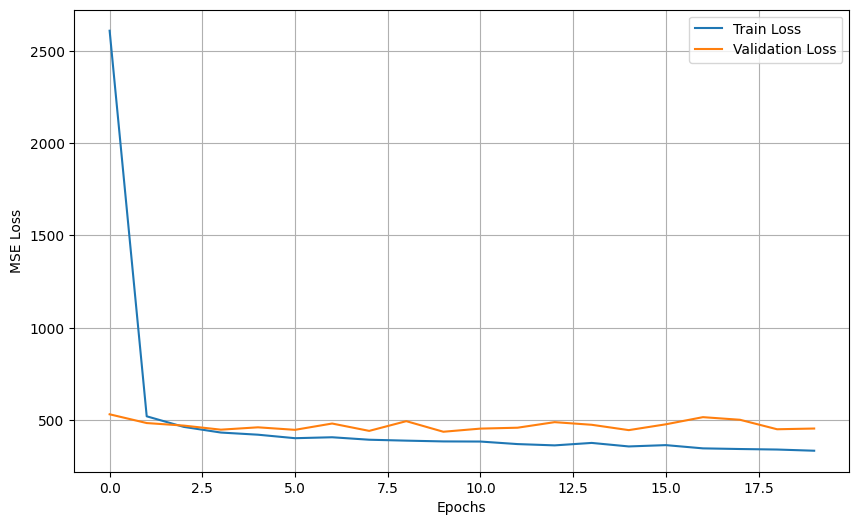

In [14]:
pipeline(dnn_30_8, epochs=epochs)

## DNN-30-16-8

In [15]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=learning_rate
)
dnn_30_16_8.model

Sequential(
  (0): Linear(in_features=31, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=16, out_features=8, bias=True)
  (5): Sigmoid()
  (6): Linear(in_features=8, out_features=1, bias=True)
)

Early stopping at epoch 38

========= Model Evaluation =========
Mean Squared Error (MSE): 389.9988
R^2 Score: 0.4964


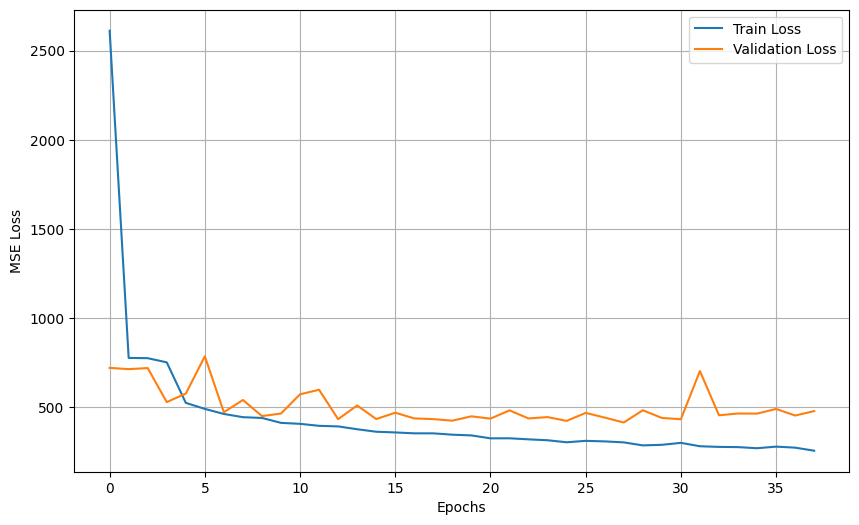

In [16]:
pipeline(dnn_30_16_8, epochs=epochs)

## DNN-30-16-8-4

In [17]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8, 4],
    output_dim=1,
    lr=learning_rate
)
dnn_30_16_8_4.model

Sequential(
  (0): Linear(in_features=31, out_features=30, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=16, out_features=8, bias=True)
  (5): Sigmoid()
  (6): Linear(in_features=8, out_features=4, bias=True)
  (7): Sigmoid()
  (8): Linear(in_features=4, out_features=1, bias=True)
)

Early stopping at epoch 47

========= Model Evaluation =========
Mean Squared Error (MSE): 395.3397
R^2 Score: 0.4895


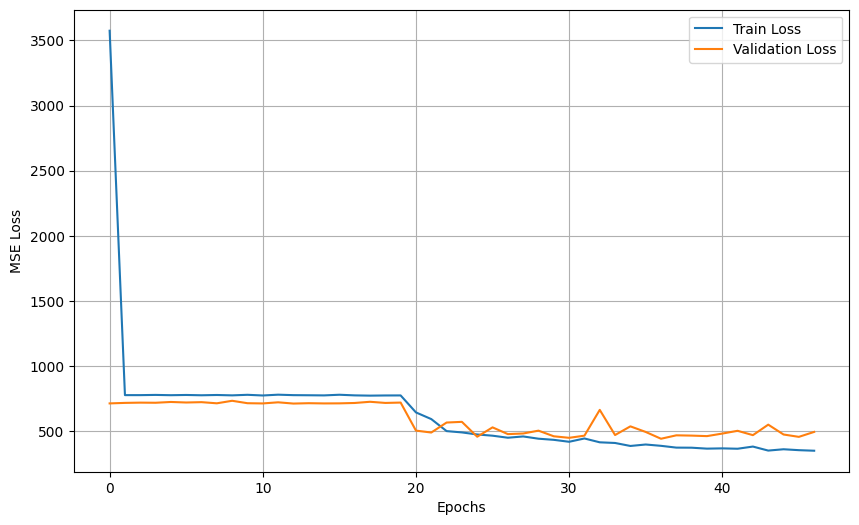

In [18]:
pipeline(dnn_30_16_8_4, epochs=epochs)